In [1]:
print("hello world")

import torch
import einops
import timm 
import skimage
import matplotlib

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0), torch.cuda.device(0))
print(torch.cuda.get_device_name(0), torch.cuda.get_device_name(1))

hello world


/wecare/home/daniel/miniconda3/envs/thesisnibabel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True
2
0
<torch.cuda.device object at 0x7fc0e5fda210> <torch.cuda.device object at 0x7fc0e5fda290>
Quadro RTX 6000 Quadro RTX 6000


/wecare/home/daniel/miniconda3/envs/thesisnibabel/lib/python3.11/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Construct runtime 2.9914612770080566


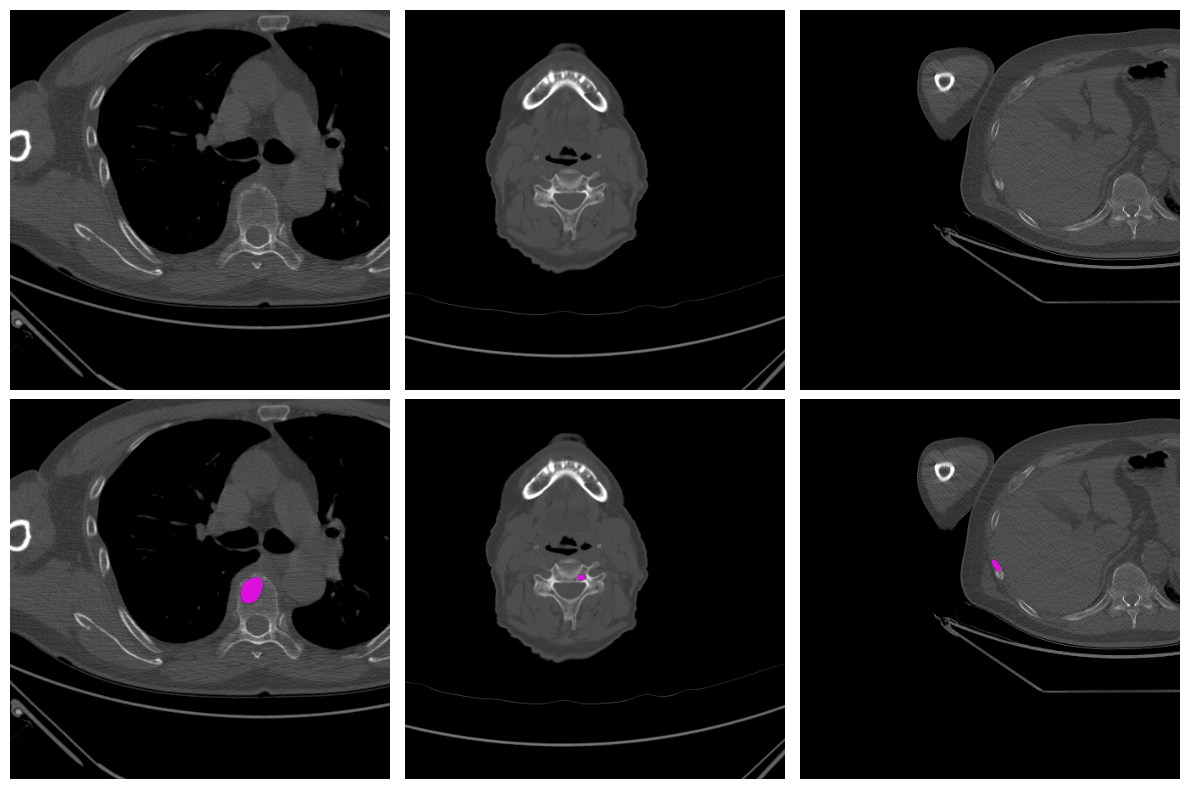

In [4]:
import data_bonelesions as kahler
import time
import torch
from torch.utils.data import DataLoader
from itertools import islice
from matplotlib import pyplot as plt
import numpy as np
import nibabel as nib

start = time.time()

# #loading original images
# origin_img_path = "/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/"
# origin_label_path = "/wecare/projects/Slicer_ready_data/Original Patient Data/Corrected_annotations/nifti/"


# origin_img1 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/CTP28_001_0000.nii')
# origin_img2 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/CTP02_001_0000.nii')
# origin_img3 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/CTP10_001_0000.nii')

# #origin_label1 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Corrected_annotations/nifti/CTP02_001.nii')
# #origin_label2 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Corrected_annotations/nifti/CTP04_001.nii')
# #origin_label3 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Corrected_annotations/nifti/CTP04_001.nii')


# origin_np_img1 = np.asanyarray(origin_img1.dataobj, dtype=np.float32)
# origin_np_img2 = np.asanyarray(origin_img2.dataobj, dtype=np.float32)
# origin_np_img3 = np.asanyarray(origin_img3.dataobj, dtype=np.float32)

#origin_np_label1 = np.asanyarray(origin_label1.dataobj, dtype=np.float32)
#origin_np_label2 = np.asanyarray(origin_label2.dataobj, dtype=np.float32)
#origin_np_label3 = np.asanyarray(origin_label3.dataobj, dtype=np.float32)


#origin_np_label1 = origin_np_label1 > 0
#origin_np_label2 = origin_np_label2 > 0
#origin_np_label3 = origin_np_label3 > 0

#origin_out_label1 = np.ma.masked_where(origin_np_label1 == 0, origin_np_label1)
#origin_out_label2 = np.ma.masked_where(origin_np_label2 == 0, origin_np_label2)
#origin_out_label3 = np.ma.masked_where(origin_np_label3 == 0, origin_np_label3)


#dataset and data loader

construct_start = time.time()

#constructing the datasets
train_img_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/images/test/"
train_mask_dir = "/wecare/home/daniel/Thesis/Dataset/448_patches/labels/test/"
train_set = kahler.KahlerDataset(train_img_dir, train_mask_dir)

#data loaders
batch_size = 1

test_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)

#test
image1, mask1 = next(islice(iter(test_loader), 77, None)) #('image_13_176_399.npy',)
image2, mask2 = next(islice(iter(test_loader), 121, None)) #('image_1_607_18.npy',)
image3, mask3 = next(islice(iter(test_loader), 298, None)) #('image_6_161_240.npy',)

construct_end = time.time()
print(f"Construct runtime {construct_end - construct_start}")

image1 = image1.squeeze().numpy()
mask1 = mask1.squeeze().numpy()
image2 = image2.squeeze().numpy()
mask2 = mask2.squeeze().numpy()
image3 = image3.squeeze().numpy()
mask3 = mask3.squeeze().numpy()

mask1 = np.ma.masked_where(mask1 == 0, mask1)
mask2 = np.ma.masked_where(mask2 == 0, mask2)
mask3 = np.ma.masked_where(mask3 == 0, mask3)

fig, axes = plt.subplots(2, 3, figsize=(12,8))


# axes[0, 0].axis('off')
# axes[0, 1].axis('off')
# axes[0, 2].axis('off')

# axes[0, 0].imshow(np.flipud(origin_np_img1[:, :, 176].T), cmap="gray")
# axes[0, 1].imshow(np.flipud(origin_np_img2[:, :, 607].T), cmap="gray")
# axes[0, 2].imshow(np.flipud(origin_np_img3[:, :, 161].T), cmap="gray")

# # axes[0, 0].imshow(mask1, alpha=0.7, cmap="summer")
# # axes[0, 1].imshow(mask2, alpha=0.7, cmap="summer")
# # axes[0, 2].imshow(mask3, alpha=0.7, cmap="summer")


axes[0, 0].axis('off')
axes[0, 1].axis('off')
axes[0, 2].axis('off')

axes[0, 0].imshow(image1, cmap="gray")
axes[0, 1].imshow(image2, cmap="gray")
axes[0, 2].imshow(image3, cmap="gray")

# axes[0, 0].imshow(mask1, alpha=0.7, cmap="summer")
# axes[0, 1].imshow(mask2, alpha=0.7, cmap="summer")
# axes[0, 2].imshow(mask3, alpha=0.7, cmap="summer")

axes[1, 0].axis('off')
axes[1, 1].axis('off')
axes[1, 2].axis('off')

axes[1, 0].imshow(image1, cmap="gray")
axes[1, 1].imshow(image2, cmap="gray")
axes[1, 2].imshow(image3, cmap="gray")

axes[1, 0].imshow(mask1, alpha=0.8, cmap="spring")
axes[1, 1].imshow(mask2, alpha=0.8, cmap="spring")
axes[1, 2].imshow(mask3, alpha=0.8, cmap="spring")

fig.tight_layout()

plt.savefig("/wecare/home/daniel/Thesis/images/448_patch_examples.png")


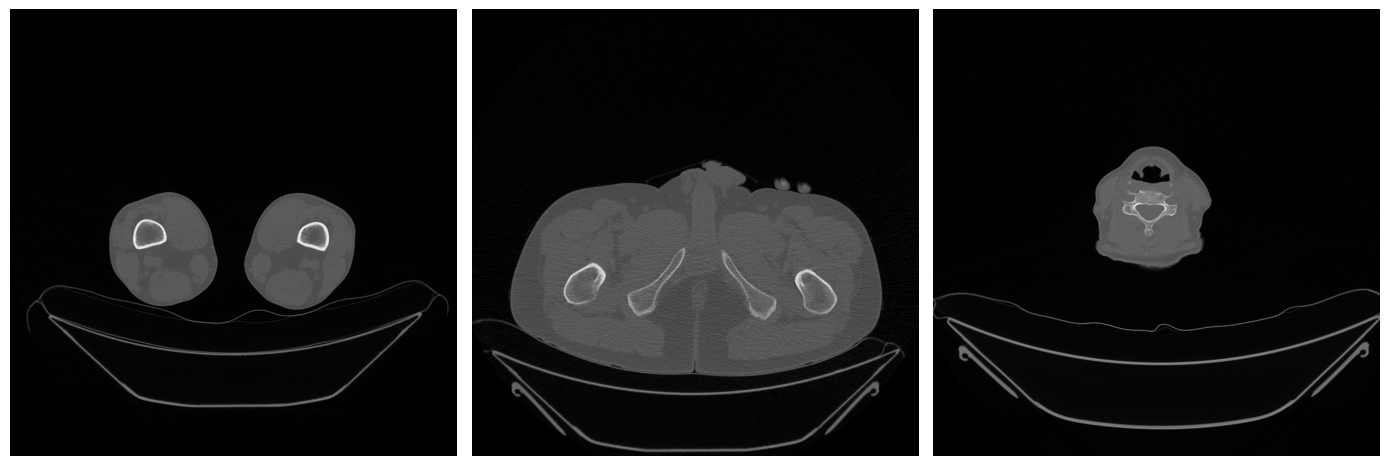

In [5]:
from matplotlib import pyplot as plt
import numpy as np
import nibabel as nib

#img = np.load("/wecare/home/daniel/Thesis/Dataset/224_patches/images/test/")

img_path = "/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/"
label_path = "/wecare/projects/Slicer_ready_data/Original Patient Data/Corrected_annotations/nifti/"

img1 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/CTP04_001_0000.nii')
img2 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/CTP07_001_0000.nii')
img3 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Images_nii/CTP10_001_0000.nii')

label1 = nib.load('/wecare/projects/Slicer_ready_data/Original Patient Data/Corrected_annotations/nifti/CTP04_001.nii')

np_img1 = np.asanyarray(img1.dataobj, dtype=np.float32)
np_img2 = np.asanyarray(img2.dataobj, dtype=np.float32)
np_img3 = np.asanyarray(img3.dataobj, dtype=np.float32)

np_label1 = np.asanyarray(label1.dataobj, dtype=np.float32)

np_label1 = np_label1 > 0

out_label1 = np.ma.masked_where(np_label1 == 0, np_label1)

#plt.figure()
#plt.imshow(np.flipud(np_img[:, :, 400].T), cmap="gray")

fig, axes = plt.subplots(1, 3, figsize=(14,5))

axes[0].axis('off')
axes[1].axis('off')
axes[2].axis('off')

axes[0].imshow(np.flipud(np_img1[:, :, 240].T), cmap="gray")
axes[1].imshow(np.flipud(np_img2[:, :, 320].T), cmap="gray")
axes[2].imshow(np.flipud(np_img3[:, :, 250].T), cmap="gray")

fig.tight_layout()
#axes[0].imshow(np.flipud(np_label1[:, :, 422].T), alpha=0.7, cmap="summer")
#axes[1].imshow(np.flipud(np_label1[:, :, 586].T), alpha=0.7, cmap="summer")
#axes[2].imshow(np.flipud(np_label1[:, :, 607&180].T), alpha=0.7, cmap="summer")

plt.savefig("/wecare/home/daniel/Thesis/images/ct_examples2.png")



In [36]:
import os
import numpy as np

images_path='/wecare/home/daniel/Thesis/Dataset/448_patches/images/train/'
labels_path='/wecare/home/daniel/Thesis/Dataset/448_patches/labels/train/'
img_files = os.listdir(images_path)
label_files = os.listdir(labels_path)

img_files.sort()
label_files.sort()

print(len(img_files), len(label_files))

for img_file, label_file in zip(img_files, label_files):
    img_path = os.path.join(images_path, img_file)
    label_path = os.path.join(labels_path, label_file)
    image = np.load(img_path)
    #image = np.expand_dims(image, axis=0)
    if image.shape[0] == 0 or image.shape[1] == 0 :
        print(img_file)
        print(image.shape)
        #os.remove(img_path)
        #os.remove(label_path)

print(len(img_files), len(label_files))

0 0
0 0
